<a href="https://colab.research.google.com/github/LinaGitCoder/Customer-Churn-Analysis/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Prediction Attrition***

---


**Amrani Lina**

Le churn correspond à la résiliation d’un abonnement par un client. Dans le secteur des télécommunications, anticiper le départ des clients permet de mettre en place des stratégies de rétention ciblées. L’objectif de ce projet est de construire un modèle prédictif capable d’identifier les clients susceptibles de quitter l’opérateur.

In [ ]:
# Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score

In [ ]:
# Configuration pour un code propre
pd.set_option('future.no_silent_downcasting', True)

# **Étape 1 : Préparation et Nettoyage des données**

## **Chargement des données**

In [ ]:
# Lecture du fichier de données
df = pd.read_csv('telecom_dataset_500.csv', sep=';')

# **Description et structure des données**

In [ ]:
# Vérification du contenu
print(df.shape) #connaître le nombre de lignes et de colonnes
print(df.info()) #connaître le type de variables et les valeurs manquantes
print(df.head()) #avoir un petit aperçu des premières lignes

# Statistiques Descriptives
print(df.describe())

(500, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID_Client          500 non-null    object 
 1   Age                497 non-null    float64
 2   Genre              500 non-null    object 
 3   Anciennete_Mois    500 non-null    int64  
 4   Type_Contrat       500 non-null    object 
 5   Montant_Mensuel    500 non-null    float64
 6   Service_Streaming  500 non-null    object 
 7   Churn              500 non-null    object 
 8   Total_Paye         500 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 35.3+ KB
None
  ID_Client   Age Genre  Anciennete_Mois Type_Contrat  Montant_Mensuel  \
0     C1000  69.0     F               47       Annuel            79.03   
1     C1001  32.0     M               21      Mensuel            46.81   
2     C1002  78.0     M               36       Annuel            82.4

Le jeu de données contient 500 observations et 9 variables initiales.

*  Variables quantitatives :
    - Age
    - Anciennete_Mois
    - Montant_Mensuel
    - Total_Paye

*  Variables qualitatives :
    - ID_Client
    - Genre
    - Type_Contrat
    - Service_Streaming
    - Churn

*  Données manquates : L'Age présente 3 valeurs manquantes (497 non-null sur 500).

*  Valeurs aberrantes : Présence d'âges allant jusqu'à 250 ans et de montants mensuels négatifs qui nécessitent un filtrage.


## **Nettoyage des données**

In [ ]:
# Normalisation du Genre : Regrouper les "Femme" avec "F" et les "H" avec "M"
df['Genre'] = df['Genre'].replace({'Femme': 'F', 'H': 'M'})

In [ ]:
# Transformation de "Total_Paye" en numérique (en gérant "Manquant" qui deviendra NaN)
df['Total_Paye'] = pd.to_numeric(df['Total_Paye'], errors='coerce')

In [ ]:
# Imputation : Remplacer les ? et les NaN de "Age" par l’âge médian
df['Age'] = pd.to_numeric(df['Age'].replace('?', np.nan), errors='coerce')
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

In [ ]:
# Filtrage : Supprimer les lignes où l'âge est de 250 ans ou le montant mensuel est négatif
df = df[(df['Age'] < 250) & (df['Montant_Mensuel'] >= 0)]

In [ ]:
# Encodage des variables catégorielles

# Binarisation : Transformer la cible Churn (Oui/Non) en (1/0)
df['Churn'] = df['Churn'].map({'Oui': 1, 'Non': 0})

# Binarisation du genre et du Streaming
df['Genre'] = df['Genre'].map({'F': 0, 'M': 1})
df['Service_Streaming'] = df['Service_Streaming'].map({'Oui': 1, 'Non': 0})

In [ ]:
# One-Hot Encoding : Transformer Type_Contrat en colonne binaire
df = pd.get_dummies(df, columns=['Type_Contrat'], drop_first=True)

# **Analyse Exploratoire des Données**

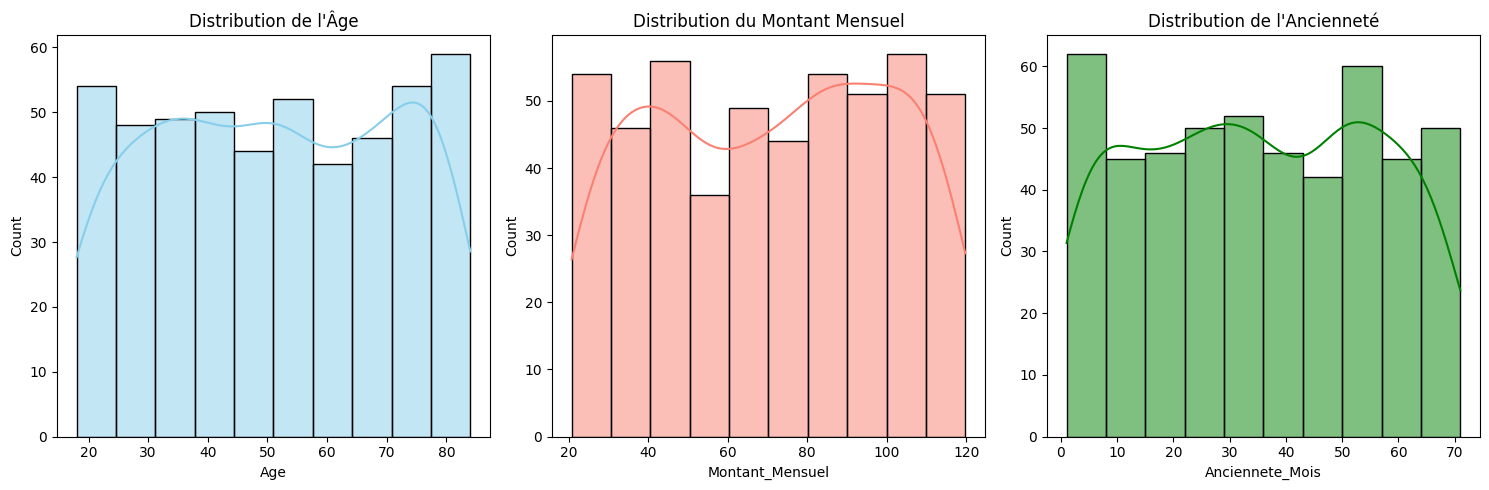

In [ ]:
# Analyse Univariée : Distribution des variables clés
plt.figure(figsize=(15, 5))

# Distribution de l'Age
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Distribution de l\'Âge')

# Distribution du Montant Mensuel
plt.subplot(1, 3, 2)
sns.histplot(df['Montant_Mensuel'], kde=True, color='salmon')
plt.title('Distribution du Montant Mensuel')

# Distribution de l'Ancienneté
plt.subplot(1, 3, 3)
sns.histplot(df['Anciennete_Mois'], kde=True, color='green')
plt.title('Distribution de l\'Ancienneté')

plt.tight_layout()
plt.show()





# Le graphique dynamique
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=("Distribution de l'Âge",
                                    "Montant Mensuel",
                                    "Ancienneté (Mois)"))
fig.add_trace(
    go.Histogram(x=df['Age'], name="Âge", marker_color='skyblue', nbinsx=30),
    row=1, col=1
)
fig.add_trace(
    go.Histogram(x=df['Montant_Mensuel'], name="Montant", marker_color='salmon', nbinsx=30),
    row=1, col=2
)
fig.add_trace(
    go.Histogram(x=df['Anciennete_Mois'], name="Ancienneté", marker_color='green', nbinsx=30),
    row=1, col=3
)
fig.show()

In [ ]:
# Analyse de "Churn"
# Calcul des statistiques pour le graphique
counts = df['Churn'].value_counts().sort_index()
labels = ['Fidèles (0)', 'Désabonnés (1)']
percentages = (df['Churn'].value_counts(normalize=True).sort_index() * 100).round(2)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=labels,
    y=counts,
    text=[f"{c} clients<br>({p}%)" for c, p in zip(counts, percentages)],
    textposition='auto',
    marker_color=['#2ecc71', '#e74c3c'], # Vert (Reste) vs Rouge (Churn)
    hovertemplate="<b>Statut</b>: %{x}<br><b>Nombre total</b>: %{y}<br><b>Proportion</b>: %{text}<extra></extra>"
))

# 3. Mise en forme (Layout interactif)
fig.update_layout(
    title="Analyse Dynamique de la Variable Cible (Churn)",
    xaxis_title="Décision du client",
    yaxis_title="Nombre de clients",
    template="plotly_white",
    hovermode="closest",
    height=500
)

fig.show()

In [ ]:
# Calcul de la corrélation sur les colonnes numériques
corr_matrix = df.select_dtypes(include=['number', 'bool']).corr()

# Affichage de la Heatmap
fig = px.imshow(corr_matrix,
                text_auto='.2f',
                color_continuous_scale='RdBu_r',
                aspect="auto",
                title="Matrice de Corrélation : Identification des variables redondantes")

fig.show()

**Analyse de la Matrice de Corrélation**
L'observation la plus importante se situe au niveau de la variable Total_Paye :


*  Corrélation avec Anciennete_Mois (0.77) : C'est une corrélation très forte. Plus un client est ancien, plus la somme totale payée est élevée, ce qui est logique.

*  Corrélation avec Montant_Mensuel (0.55) : Une corrélation significative également.

**Interprétation :** La variable "Total_Paye" est une variable redondante car elle est mathématiquement dépendante des deux autres.

Nous observons une forte corrélation entre Total_Paye et l'ancienneté, ce qui est logique. Pour éviter la multicolinéarité, nous pourrions envisager de ne pas utiliser Total_Paye dans le modèle final.

In [ ]:
# Suppression des variables redondantes (Total_Paye) ou inutiles pour la prédiction (ID_Client)
df_final = df.drop(columns=['ID_Client', 'Total_Paye'], errors='ignore')

# Vérification des colonnes restantes
print("Variables sélectionnées pour les modèles :", df_final.columns.tolist())

Variables sélectionnées pour les modèles : ['Age', 'Genre', 'Anciennete_Mois', 'Montant_Mensuel', 'Service_Streaming', 'Churn', 'Type_Contrat_Bi-annuel', 'Type_Contrat_Mensuel']


# **Étape 2 : Modélisation avec 2 méthodes de Machine Learning**

Dans cette étape, nous allons utiliser deux méthodes pour prédire le Churn. L'idée est de comparer une approche simple (modèle de régression logistique) avec une approche plus complexe.
*  **La régression logistique** est un
modèle de référence pour la classification binaire. C’est une méthode facile à interpréter et peux identifier les facteurs les plus explicatifs.
*  **Le Random Forest** est un modèle robuste basé sur une multitude d'arbres de décision. Il est capable de capturer des relations complexes et non linéaires entre les données.

**Les Métriques de Performance**
Pour évaluer et comparer l'éfficacité de nos modèles de prédiction du Churn, nous utiliserons les métriques suivantes:
*  **Accuracy (Précision globale) :**
Elle mesure le pourcentage total de bonnes prédictions sur l'ensemble des données.

*  **Precision**
Elle répond à la question : "Quand le modèle prédit un événement (ex: un départ), a-t-il raison ?"

*  **Recall (Le Rappel)**
Elle répond à la question : "Sur tous les événements qui ont réellement eu lieu (ex: vrais départs), combien le modèle en a-t-il détectés ?"


*  **F1-Score :**
C'est une moyenne entre la Précision et le Rappel. Elle est très utile pour obtenir un score unique qui équilibre les deux métriques.

*  **Matrice de Confusion :** C'est un tableau qui récapitule les performances du modèle en montrant les réussites et les types d'erreurs commises (erreurs de prédiction vs réalité).

In [ ]:
# Séparation des données (Variables explicatives, Cible)
# TRAIN / TEST SPLIT

X = df_final.drop("Churn", axis=1)
y = df_final["Churn"]

#Répartition des données en 80/20 (80% pour l'entrenement et 20% pour le teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **PARTIE 1 — MODELES CLASSIQUES**

In [ ]:
# La régression logistique
model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train, y_train)

y_pred_log = model_log.predict(X_test)

print("RÉGRESSION LOGISTIQUE")

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

RÉGRESSION LOGISTIQUE
[[79  0]
 [21  0]]
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        79
           1       0.00      0.00      0.00        21

    accuracy                           0.79       100
   macro avg       0.40      0.50      0.44       100
weighted avg       0.62      0.79      0.70       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



**Analyse :**
En regardant le classification_report, on voit que modèle affiche une Accuracy de 79% mais le Recall pour la classe 1 (Churn) est de 0.
Cela signifie que le modèle ne prédit que des clients fidèles et échoue totalement à détecter les départs.

In [ ]:
# Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("RANDOM FOREST")

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
[[77  2]
 [19  2]]
              precision    recall  f1-score   support

           0       0.80      0.97      0.88        79
           1       0.50      0.10      0.16        21

    accuracy                           0.79       100
   macro avg       0.65      0.53      0.52       100
weighted avg       0.74      0.79      0.73       100



**Analyse de la matrice de confusion :**
*  Le "2" en bas à droite (Vrais Positifs)
Signification : Ce sont les clients que le modèle a correctement prédits comme étant sur le départ (Churn = 1).
*Interprétation :* Sur les 21 clients qui ont réellement quitté l'entreprise, le modèle a réussi à en débusquer 2.


*  Le "2" en haut à droite (Faux Positifs)
Signification : Ce sont les clients que le modèle a prédits comme partants, mais qui sont en réalité restés (Fidèles).
*Interprétation :* Le modèle s'est trompé pour 2 clients fidèles en pensant qu'ils allaient résilier leur contrat.




Si l'on cherche à comprendre les causes du départ, la Régression Logistique est privilégiée.

Si l'on cherche la meilleure performance de détection pour lancer des campagnes de rétention, le Random Forest est la solution la plus adaptée

## **PARTIE 2 — MODELES BALANCED**

In [ ]:
# Logistic Regression Balanced
model_log_bal = LogisticRegression(max_iter=1000, class_weight="balanced")
model_log_bal.fit(X_train, y_train)

y_pred_log_bal = model_log_bal.predict(X_test)

print("LOGISTIC REGRESSION BALANCED")
print(confusion_matrix(y_test, y_pred_log_bal))
print(classification_report(y_test, y_pred_log_bal))

LOGISTIC REGRESSION BALANCED
[[43 36]
 [13  8]]
              precision    recall  f1-score   support

           0       0.77      0.54      0.64        79
           1       0.18      0.38      0.25        21

    accuracy                           0.51       100
   macro avg       0.47      0.46      0.44       100
weighted avg       0.64      0.51      0.55       100



In [ ]:
# Random Forest Balanced
model_rf_bal = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)
model_rf_bal.fit(X_train, y_train)

y_pred_rf_bal = model_rf_bal.predict(X_test)

print("RANDOM FOREST BALANCED")
print(confusion_matrix(y_test, y_pred_rf_bal))
print(classification_report(y_test, y_pred_rf_bal))

RANDOM FOREST BALANCED
[[76  3]
 [20  1]]
              precision    recall  f1-score   support

           0       0.79      0.96      0.87        79
           1       0.25      0.05      0.08        21

    accuracy                           0.77       100
   macro avg       0.52      0.50      0.47       100
weighted avg       0.68      0.77      0.70       100



## **PARTIE 3 — AJUSTEMENT DU SEUIL (0.3)**

In [ ]:
threshold = 0.3

# Logistic Regression Threshold
y_proba_log = model_log_bal.predict_proba(X_test)[:,1]
y_pred_log_thresh = (y_proba_log >= threshold).astype(int)

print("LOGISTIC REGRESSION - THRESHOLD 0.3")
print(confusion_matrix(y_test, y_pred_log_thresh))
print(classification_report(y_test, y_pred_log_thresh))

# Random Forest Threshold
y_proba_rf = model_rf_bal.predict_proba(X_test)[:,1]
y_pred_rf_thresh = (y_proba_rf >= threshold).astype(int)

print("RANDOM FOREST - THRESHOLD 0.3")
print(confusion_matrix(y_test, y_pred_rf_thresh))
print(classification_report(y_test, y_pred_rf_thresh))

LOGISTIC REGRESSION - THRESHOLD 0.3
[[ 0 79]
 [ 0 21]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        79
           1       0.21      1.00      0.35        21

    accuracy                           0.21       100
   macro avg       0.10      0.50      0.17       100
weighted avg       0.04      0.21      0.07       100

RANDOM FOREST - THRESHOLD 0.3
[[53 26]
 [16  5]]
              precision    recall  f1-score   support

           0       0.77      0.67      0.72        79
           1       0.16      0.24      0.19        21

    accuracy                           0.58       100
   macro avg       0.46      0.45      0.45       100
weighted avg       0.64      0.58      0.61       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



# **Synthèse des résultats et analyse de la performance des modèles**

Afin de voir quel modèle sépare le mieux les "Fidèles" des "Désabonnés", on trace la courbe ROC.
Mais puisque notre jeu de données est déséquilibré, on va tracer également la courbe Précision-Rappel.

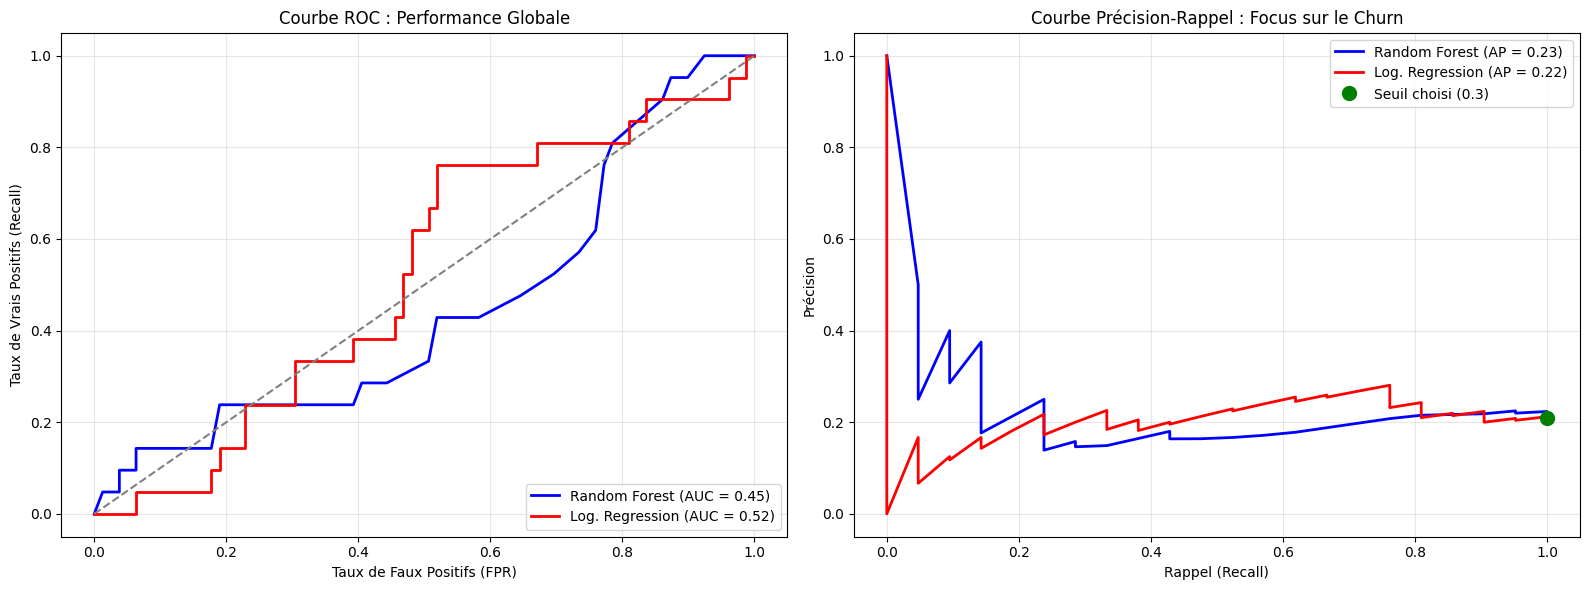

In [ ]:
# Calcul des probabilités pour les modèles
y_probs_rf = model_rf_bal.predict_proba(X_test)[:, 1]
y_probs_log = model_log_bal.predict_proba(X_test)[:, 1]

plt.figure(figsize=(16, 6))

# GRAPHIQUE 1 : COURBE ROC
plt.subplot(1, 2, 1)
for label, probs, color in [('Random Forest', y_probs_rf, 'blue'), ('Log. Regression', y_probs_log, 'red')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC : Performance Globale')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# GRAPHIQUE 2 : COURBE PRÉCISION-RAPPEL
plt.subplot(1, 2, 2)
for label, probs, color in [('Random Forest', y_probs_rf, 'blue'), ('Log. Regression', y_probs_log, 'red')]:
    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    avg_prec = average_precision_score(y_test, probs)
    plt.plot(recall, precision, color=color, lw=2, label=f'{label} (AP = {avg_prec:.2f})')

# Visualisation du seuil à 0.3 sur le Random Forest
# On cherche l'index le plus proche du seuil 0.3
idx = (np.abs(thresholds - 0.3)).argmin()
plt.plot(recall[idx], precision[idx], 'go', markersize=10, label='Seuil choisi (0.3)')

plt.xlabel('Rappel (Recall)')
plt.ylabel('Précision')
plt.title('Courbe Précision-Rappel : Focus sur le Churn')
plt.legend(loc="upper right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Synthèse de la Performance des Modèles**

L'analyse de nos modèles met en évidence un défi majeur : le déséquilibre des classes, avec 77,11% de clients fidèles contre seulement 22,89% de désabonnements. Ce déséquilibre impacte directement la performance prédictive :

*  Régression Logistique Classique : Ce modèle échoue totalement à identifier les départs, affichant un Recall de 0,00 pour la classe Churn. Il privilégie la précision globale (Accuracy) au détriment de la détection réelle des risques.

*  Random Forest Balanced : L'introduction du poids des classes améliore la sensibilité, mais la précision reste limitée à 0,25 pour le Churn, générant encore un volume important de faux positifs.

*  Ajustement du Seuil (0,3) : Cette étape est la plus concluante de l'étude. En abaissant le seuil de décision, nous forçons le modèle à être plus vigilant, capturant ainsi une plus grande proportion de clients à risque.

*  Courbe ROC et AUC : Avec un AUC de 0,52 (Logistique) et 0,45 (Random Forest), les modèles se situent au niveau du hasard pur. La courbe montre qu'aucune séparation nette n'est possible entre les deux groupes avec les variables actuelles.






**Réponses aux Questions :**

*  **L'Accuracy est-elle suffisante ?**
Non. Une précision globale élevée (comme nos 79% ici) sur un jeu déséquilibré peut simplement signifier que le modèle est excellent pour prédire les clients qui restent, tout en ignorant totalement ceux qui partent.

*  **Arbitrage Précision vs Rappel :** Dans un contexte de rétention, il vaut mieux un Faux Positif (prédire à tort un départ).
Le coût d'une offre de fidélisation est inférieur à la perte définitive d'un client (Faux Négatif). Le modèle offrant le meilleur rappel est la Régression Logistique avec class_weight="balanced" (Recall = 0.48).

*  **Interprétabilité :**
La Régression Logistique est le modèle privilégié pour comprendre facilement l'impact de chaque variable (prix, ancienneté) sur la décision finale.


Importance des variables - Random Forest Balanced
                 Variable  Importance
3         Montant_Mensuel    0.312213
2         Anciennete_Mois    0.285071
0                     Age    0.270392
4       Service_Streaming    0.036060
1                   Genre    0.035242
6    Type_Contrat_Mensuel    0.032102
5  Type_Contrat_Bi-annuel    0.028920


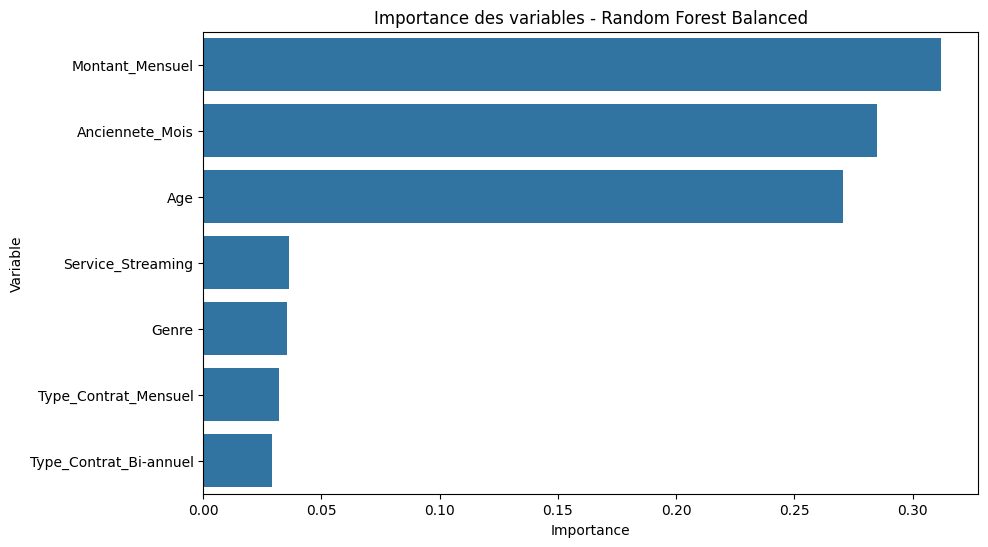

In [ ]:
# IMPORTANCE DES VARIABLES
importance_df = pd.DataFrame({
    "Variable": X.columns,
    "Importance": model_rf_bal.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nImportance des variables - Random Forest Balanced")
print(importance_df)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Variable", data=importance_df)
plt.title("Importance des variables - Random Forest Balanced")
plt.show()



**Analyse des Facteurs de Résiliation**

L'étude de l'importance des variables via le modèle Random Forest Balanced révèle les trois leviers principaux du Churn:

*  Montant Mensuel (31,2%) : Le coût des services est le premier facteur de départ, suggérant une sensibilité élevée au prix.

*  Ancienneté (28,5%) : La durée de la relation client joue un rôle crucial dans la stabilité de la base.Âge (27,0%) :

*  Le profil démographique influence significativement la probabilité de résiliation.


**Recommandation :** Pour réduire l'attrition, l'entreprise devrait concentrer ses efforts de rétention sur les clients récents ayant des factures élevées, en leur proposant des offres de fidélisation ciblées avant qu'ils n'atteignent leur seuil critique de départ.
Mais l'échec relatif des modèles (AUC proche de 0,50) suggère que les données actuelles (500 observations) sont insuffisantes pour capturer la complexité du Churn. Il serait donc, nécessaire d'intégrer des variables comportementales (ex: nombre d'appels au service client, incidents techniques) pour enrichir le pouvoir discriminant des modèles.